## Figure 5 and supplement: Peptide detection - Across DIVs ##

Scripts plot peptides across DIVs from a comprehensive list of detected peptides exported from Perseus. Scripts require .csv of peptides, and used Stripped.Sequence for detection.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

In [20]:
askmastersheet = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askmastersheet, encoding='utf-8')
data

,DCX_DIV2_3,DCX_DIV2_1,DCX_DIV2_2,DCX_DIV3_2,DCX_DIV3_3,DCX_DIV3_1,DCX_DIV4_2,DCX_DIV4_3,DCX_DIV4_1,DCX_DIV5_3,...,Valid values DCX_DIV2,Valid values DCX_DIV3,Valid values DCX_DIV4,Valid values DCX_DIV5,Protein.Group,Protein.Ids,Genes,Stripped.Sequence,Modified.Sequence,Precursor.Id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,1,P60660,P60660,MYL6,CDFTEDQTAEFK,(UniMod:1)C(UniMod:6)DFTEDQTAEFK,(UniMod:1)C(UniMod:6)DFTEDQTAEFK2
1,13.161823,13.811836,13.616859,13.663647,13.371859,14.243635,16.251892,16.420309,16.383596,11.507507,...,3,3,3,3,P07197,P07197,NEFM,SYTLDSLGNPSAYR,(UniMod:1)SYTLDSLGNPSAYR,(UniMod:1)SYTLDSLGNPSAYR2
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,2,P07197,P07197,NEFM,SYTLDSLGNPSAYRR,(UniMod:1)SYTLDSLGNPSAYRR,(UniMod:1)SYTLDSLGNPSAYRR3
3,10.898602,12.568585,11.086840,10.072682,NaN,11.177039,13.472564,13.690424,13.413086,15.722906,...,3,2,3,4,Q96JE9,Q96JE9,MAP6,AAADALNR,AAADALNR,AAADALNR2
4,12.985337,13.526156,12.752891,NaN,NaN,NaN,14.359879,NaN,NaN,14.532477,...,3,0,1,3,Q7Z460,Q7Z460,CLASP1,AAEEAASTLASSIHPEQCIK,AAEEAASTLASSIHPEQC(UniMod:6)IK,AAEEAASTLASSIHPEQC(UniMod:6)IK3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
636,13.655296,14.313896,13.954932,12.866342,11.503617,11.681713,13.795187,13.708286,13.259371,NaN,...,3,3,3,1,P78559,P78559,MAP1A,YSAQTDITDDSLDR,YSAQTDITDDSLDR,YSAQTDITDDSLDR2
637,NaN,9.939763,NaN,NaN,NaN,NaN,10.010011,NaN,NaN,NaN,...,1,0,1,1,P78559,P78559,MAP1A,YSAQTDITDDSLDRK,YSAQTDITDDSLDRK,YSAQTDITDDSLDRK2
638,NaN,NaN,NaN,NaN,NaN,NaN,11.752389,11.591551,NaN,NaN,...,0,0,2,1,Q96JE9,Q96JE9,MAP6,YSEATEHPGAPPQPPPPQQQAQPALAPPSAR,YSEATEHPGAPPQPPPPQQQAQPALAPPSAR,YSEATEHPGAPPQPPPPQQQAQPALAPPSAR4
639,12.009367,11.955585,NaN,NaN,NaN,10.682670,12.573507,11.616760,NaN,NaN,...,2,1,2,1,Q8NHV4,Q8NHV4,NEDD1,YSVNEGLVAEIER,YSVNEGLVAEIER,YSVNEGLVAEIER2


In [21]:
#Create plots folder

pathmastersheet = Path(askmastersheet)
resultdirectory = str(pathmastersheet.parents[0])+'//Plots'
newmydir = Path(resultdirectory)
newmydir.mkdir(exist_ok=True)
path = newmydir
path

WindowsPath('C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/Curated_Cytoskeleton/Plots')

## Figure 5: Bar chart - peptides detected by gene across DIVs ##

Script uses matplotlib to parse all detected peptides for called genes. 

In [18]:
def tally_peptides_by_gene_and_div(
    df,
    threshold=2,
    gene_col="Genes",
    gene_list=None
):
    import pandas as pd

    valid_cols = {
        "DIV2": "Valid values DCX_DIV2",
        "DIV3": "Valid values DCX_DIV3",
        "DIV4": "Valid values DCX_DIV4",
        "DIV5": "Valid values DCX_DIV5",
    }

    sub = df.copy()

    # Clean gene column
    sub[gene_col] = sub[gene_col].astype(str).str.strip()

    # Filter to requested genes only
    if gene_list is not None:
        gene_list = [g.strip() for g in gene_list]
        sub = sub[sub[gene_col].isin(gene_list)]

        if sub.empty:
            print(f"No matching genes found for: {gene_list}")
            return None

    # Make sure valid-value columns are numeric
    for col in valid_cols.values():
        sub[col] = pd.to_numeric(sub[col], errors="coerce")

    # Count peptides per gene per DIV
    records = []
    for div, col in valid_cols.items():
        counts = sub.groupby(gene_col)[col].apply(lambda x: (x >= threshold).sum())
        counts.name = div
        records.append(counts)

    summary = pd.concat(records, axis=1).fillna(0).astype(int)

    # Keep only requested genes and preserve order
    if gene_list is not None:
        existing = [g for g in gene_list if g in summary.index]
        summary = summary.loc[existing]

    # Flip so DIVs are rows and genes are columns
    summary = summary.T

    return summary


def plot_peptides_by_gene(
    summary,
    gene_order=None,
    title="Detected peptides by Gene across DIVs",
    save_path=None
):
    import matplotlib.pyplot as plt
    import numpy as np

    if summary is None or summary.empty:
        print("Summary is empty. Nothing to plot.")
        return

    plot_data = summary.copy()

    # Strictly keep only requested genes, in requested order
    if gene_order is not None:
        existing = [g for g in gene_order if g in plot_data.columns]
        plot_data = plot_data[existing]

        if plot_data.empty:
            print("None of the requested genes are present in the summary.")
            return

    # Lighter greys + stronger hatches for better distinction
    greys = ["#e6e6e6", "#c9c9c9", "#a6a6a6", "#7f7f7f", "#d9d9d9", "#bfbfbf"]
    hatches = ["", "///", "xxx", "ooo", "\\\\\\", "---", "|||", "++"]

    n_rows = plot_data.shape[0]
    n_cols = plot_data.shape[1]
    x = np.arange(n_rows)
    group_width = 0.8
    bar_width = group_width / n_cols

    fig, ax = plt.subplots(figsize=(8, 4))

    for j, gene in enumerate(plot_data.columns):
        offsets = x - group_width / 2 + j * bar_width + bar_width / 2
        values = plot_data[gene].values

        ax.bar(
            offsets,
            values,
            width=bar_width,
            color=greys[j % len(greys)],
            edgecolor="black",
            linewidth=1.0,
            hatch=hatches[j % len(hatches)],
            label=gene
        )

    # Set y-limits
    nonzero = plot_data.values[plot_data.values > 0]
    if len(nonzero) > 0:
        ymax = np.max(plot_data.values) + 1
    else:
        ymax = 1

    ax.set_ylim(0, ymax)

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Number of peptides")
    ax.set_xlabel("DIV")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data.index, rotation=0)

    # Add small marker for zero values
    zero_y = ymax * 0.015

    for i, div in enumerate(plot_data.index):
        for j, gene in enumerate(plot_data.columns):
            val = plot_data.loc[div, gene]
            if val == 0:
                xpos = i - group_width / 2 + j * bar_width + bar_width / 2
                ax.hlines(
                    y=zero_y,
                    xmin=xpos - bar_width * 0.3,
                    xmax=xpos + bar_width * 0.3,
                    linewidth=1.2,
                    color="black"
                )

    ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.savefig(path / f"Pep_1.5fold{date}.png", dpi=300, bbox_inches="tight")

    plt.show()

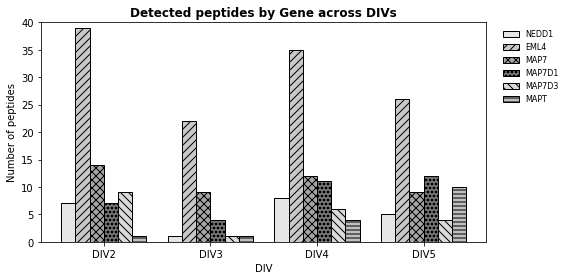

In [19]:
genes_to_plot = ["NEDD1","EML4", "MAP7", "MAP7D1", "MAP7D3", "MAPT"]

summary = tally_peptides_by_gene_and_div(
    data,
    threshold=2,
    gene_list=genes_to_plot
)

plot_peptides_by_gene(
    summary,
    gene_order=genes_to_plot,
    title="Detected peptides by Gene across DIVs"
)

## Supplement: Lineplot peptides per DIV for a single gene ##

Script calls a gene to generate a line plot for individual peptide intensities across DIVs

In [5]:
def plot_peptide_profiles_gradient(
    df,
    target,
    mode="gene",              # "gene" or "class"
    fill_value=5,
    save_path=None,
    title=None
):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors as mcolors
    import copy

    peptide_col = "Stripped.Sequence"
    gene_col    = "Genes"
    # class_col   = "DomSpec"
    div_cols    = ["Mean DCX_DIV2", "Mean DCX_DIV3", "Mean DCX_DIV4", "Mean DCX_DIV5"]
    div_labels  = ["DIV2", "DIV3", "DIV4", "DIV5"]

    # ----------------------------
    # GLOBAL COLOR SCALE
    # ----------------------------
    tmp_all = df[[peptide_col] + div_cols].copy()
    tmp_all[peptide_col] = tmp_all[peptide_col].astype(str).str.strip()

    for c in div_cols:
        tmp_all[c] = pd.to_numeric(tmp_all[c], errors="coerce")

    all_vals = tmp_all[div_cols].to_numpy(dtype=float)

    vmin = np.nanpercentile(all_vals, 5)
    vmax = np.nanpercentile(all_vals, 95)

    cmap = copy.copy(cm.get_cmap("flare"))
    cmap.set_bad("#6e6e6e")
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # ----------------------------
    # FILTER
    # ----------------------------
    sub = df.copy()
    sub[peptide_col] = sub[peptide_col].astype(str).str.strip()

    if mode == "gene":
        sub[gene_col] = sub[gene_col].astype(str).str.strip()
        sub = sub[sub[gene_col] == target]
    elif mode == "class":
        sub[class_col] = sub[class_col].astype(str).str.strip()
        sub = sub[sub[class_col] == target]
    else:
        raise ValueError("mode must be 'gene' or 'class'")

    if sub.empty:
        print(f"No data for {mode}: {target}")
        return

    for c in div_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    sub = sub.drop_duplicates(subset=[peptide_col], keep="first")

    raw_vals = sub[div_cols].to_numpy(dtype=float)
    x = np.arange(len(div_labels))

    # ----------------------------
    # AXIS SCALING
    # ----------------------------
    ymin = 8
    ymax = 22
    ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1

    # ----------------------------
    # PLOT
    # ----------------------------
    fig, ax = plt.subplots(figsize=(5, 4))

    for i, raw_row in enumerate(raw_vals):
        peptide = sub.iloc[i][peptide_col]

        # original NaN positions
        nan_positions = np.isnan(raw_row)

        # plotting row: NaNs sit at detection threshold
        row = raw_row.copy()
        row[nan_positions] = ymin

        # draw each segment separately
        for j in range(len(x) - 1):
            seg_x = x[j:j+2]
            seg_y = row[j:j+2]
            raw_pair = raw_row[j:j+2]

            # both endpoints NaN -> grey segment
            if np.all(np.isnan(raw_pair)):
                seg_color = "#6e6e6e"
            else:
                seg_metric = np.nanmean(raw_pair)
                seg_color = cmap(norm(seg_metric))

            ax.plot(
                seg_x,
                seg_y,
                linewidth=1.5,
                alpha=0.95,
                color=seg_color
            )

        # point colors reflect their own intensity; NaNs are grey
        point_colors = []
        for val in raw_row:
            if np.isnan(val):
                point_colors.append("#6e6e6e")
            else:
                point_colors.append(cmap(norm(val)))

        # circular points
        ax.scatter(x, row, s=24, c=point_colors, zorder=3)

        # square points for NaNs at detection floor
        if nan_positions.any():
            ax.scatter(
                x[nan_positions],
                row[nan_positions],
                marker="s",
                s=34,
                color="#6e6e6e",
                zorder=4
            )

        # label color = final point color, unless final point is NaN
        last_raw = raw_row[-1]
        label_color = "#6e6e6e" if np.isnan(last_raw) else cmap(norm(last_raw))

        ax.text(
            x[-1] + 0.05,
            row[-1],
            peptide,
            fontsize=7,
            va="center",
            color=label_color
        )

    ax.set_xticks(x)
    ax.set_xticklabels(div_labels, fontweight="bold")
    ax.set_ylim(ymin - 0.5, ymax + ypad)
    ax.set_xlim(-0.2, len(x) - 1 + 0.8)

    if title is None:
        title = f"{target}"

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Mean intensity")

    ax.axhline(ymin, linestyle="--", linewidth=1, alpha=0.5, color="#6e6e6e")

    sns.despine(offset=5, trim=True)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

C:\Users\Brandi\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1007: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x = np.asanyarray(x)
C:\Users\Brandi\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1007: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x = np.asanyarray(x)
C:\Users\Brandi\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1007: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If 

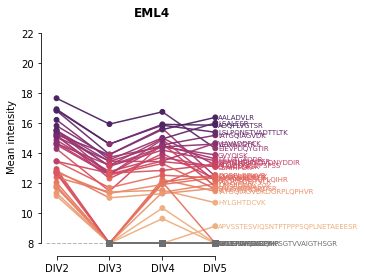

In [7]:
plot_peptide_profiles_gradient(
    data,
    target="EML4",
    mode="gene",
    save_path=path / f"EML4_peptide_lines_{date}.svg"
)

## Supplement: Bar chart of detected peptides for a gene across DIVs ##

In [9]:
def plot_detected_peptide_counts(df, threshold=2):
    import pandas as pd
    import matplotlib.pyplot as plt

    valid_cols = {
        "DIV2": "Valid values DCX_DIV2",
        "DIV3": "Valid values DCX_DIV3",
        "DIV4": "Valid values DCX_DIV4",
        "DIV5": "Valid values DCX_DIV5",
    }

    counts = {}

    for div, col in valid_cols.items():
        df[col] = pd.to_numeric(df[col], errors="coerce")
        counts[div] = (df[col] >= threshold).sum()

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(counts.keys(), counts.values())

    ax.set_title(f"Detected peptides per DIV (valid values ≥ {threshold})", fontweight="bold")
    ax.set_ylabel("Number of peptides")
    ax.set_xlabel("Stage")

    plt.tight_layout()
    plt.savefig(path / f"EML4_PepTot{date}.svg")
    plt.show()

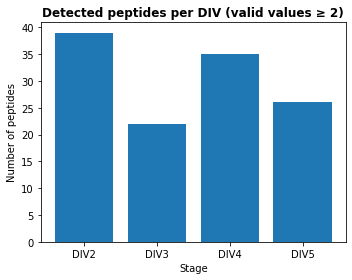

In [10]:
plot_detected_peptide_counts(data)